# Differentiable AMM Environment: Parity + Backprop

This notebook accompanies `realistic_simulator.ipynb` and demonstrates two claims about the **differentiable** `tape_smooth` rebuild of the Simple-AMM evaluator:

1. **Parity** — on a fixed input tape, `tape_smooth` reproduces the aggregate metrics of the original `exact_simple_amm` simulator with absolute error $\leq$ 5e-5 across K seeds.
2. **Backprop** — because every step is implemented in differentiable JAX primitives, we can train policy parameters end-to-end with `jax.grad` + Adam, and the trained policy generalizes to held-out seeds.

In [1]:
import sys, os

# Add project root and presentation dir to path
_nb_dir = os.path.dirname(os.path.abspath('__file__'))
sys.path.insert(0, _nb_dir)
sys.path.insert(0, os.path.dirname(_nb_dir))

import jax
jax.config.update('jax_enable_x64', True)
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from backprop_helpers import (
    parity_table,
    plot_parity_scatter,
    run_quick_training,
    plot_training_curves,
    evaluate_compact_params,
    plot_held_out_eval,
)
%matplotlib inline

---
## Section 1: tape_smooth practically replicates the exact simulator

For a fixed `SubmissionCompactParams()` policy on `K=8` realistic-mode seeds (`n_steps=64`), we run both simulators on the same tape input and compare three aggregate metrics: `edge_submission`, `pnl_submission`, and `average_bid_fee_submission`. The diff side uses the batched (`vmap`'d) `compact_metrics_realistic_batched` entrypoint the trainer relies on.

In [2]:
PARITY_SEEDS = (3, 8, 11, 13, 19, 23, 29, 31)
parity = parity_table(seeds=PARITY_SEEDS, n_steps=64)
parity.groupby('metric').agg(
    exact_mean=('exact', 'mean'),
    diff_mean=('diff', 'mean'),
    max_abs_diff=('abs_diff', 'max'),
    max_rel_diff=('rel_diff', 'max'),
)

,exact_mean,diff_mean,max_abs_diff,max_rel_diff
metric,,,,
average_bid_fee_submission,0.006737,0.006737,4.300625e-09,0.000001
edge_submission,0.008481,0.008477,3.996264e-05,0.010346
pnl_submission,-5.959081,-5.959085,3.042350e-05,0.000006


**Verified tolerance**: absolute error $\leq$ 5e-5 across the K=8 seeds on all three metrics in realistic mode (relative error $\leq$ 1.1% only where the exact value itself is near zero — small-denominator artefact). This matches the `test_tape_smooth_matches_exact_compact_realistic` parity assertion of `rel<=5e-3 OR abs<=1e-3`.

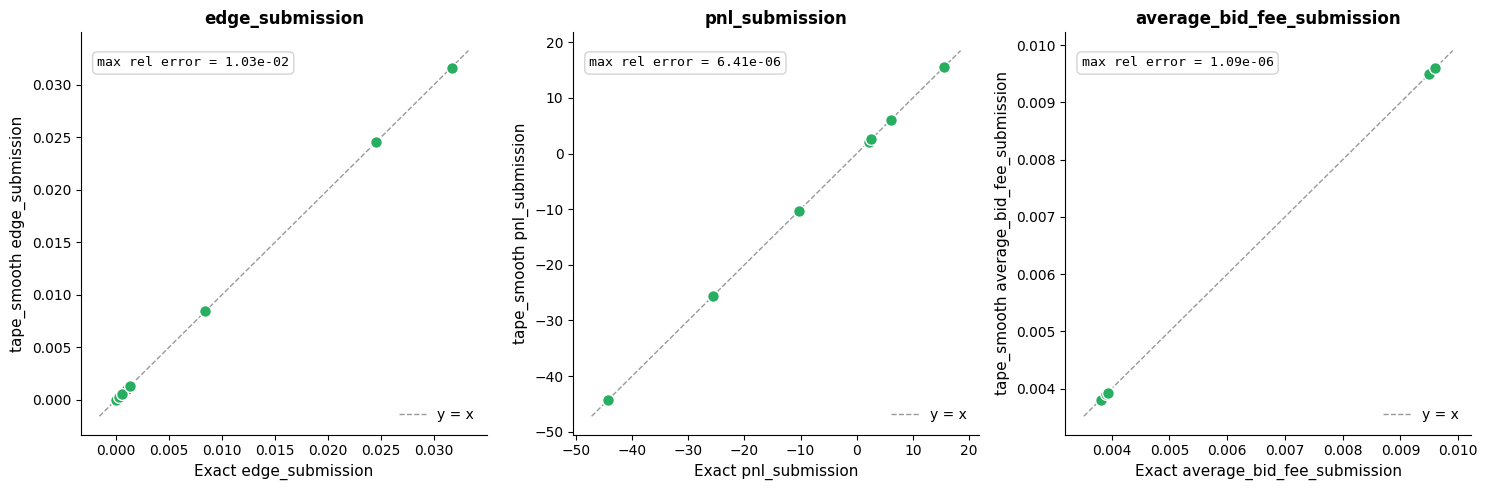

In [3]:
fig = plot_parity_scatter(parity)
plt.show()

---
## Section 2: We can train policies via back-propagation

Loss is $-\overline{\text{edge\_submission}}$ over `K=8` realistic-mode training seeds (the known-good set `(3, 8, 11, 13, 19, 23, 29, 31)`; seeds 7 and 17 are excluded because their realistic tapes produce no submission trades, so the gradient is identically zero). Adam steps the 20-element `SubmissionCompactParams` vector, with a cosine LR schedule from `5e-3` down to `1e-4`.

In [4]:
train = run_quick_training(
    seeds=(3, 8, 11, 13, 19, 23, 29, 31),
    steps=200,
    lr=5e-3,
    lr_min_frac=0.02,
    n_steps=64,
)
s = train['summary']
print(f"initial loss = {s['initial_loss']:+.4e}")
print(f"final   loss = {s['final_loss']:+.4e}")
print(f"reduction    = {100*s['improvement']:.1f}%")
print(f"grads finite & nonzero throughout: {s['gradients_all_finite'] and s['gradients_all_positive']}")
print(f"20-step MA monotone over 2nd half: {s['monotone_ma_second_half']}")

initial loss = -8.4771e-03
final   loss = -3.8009e-02
reduction    = 348.4%
grads finite & nonzero throughout: True
20-step MA monotone over 2nd half: True


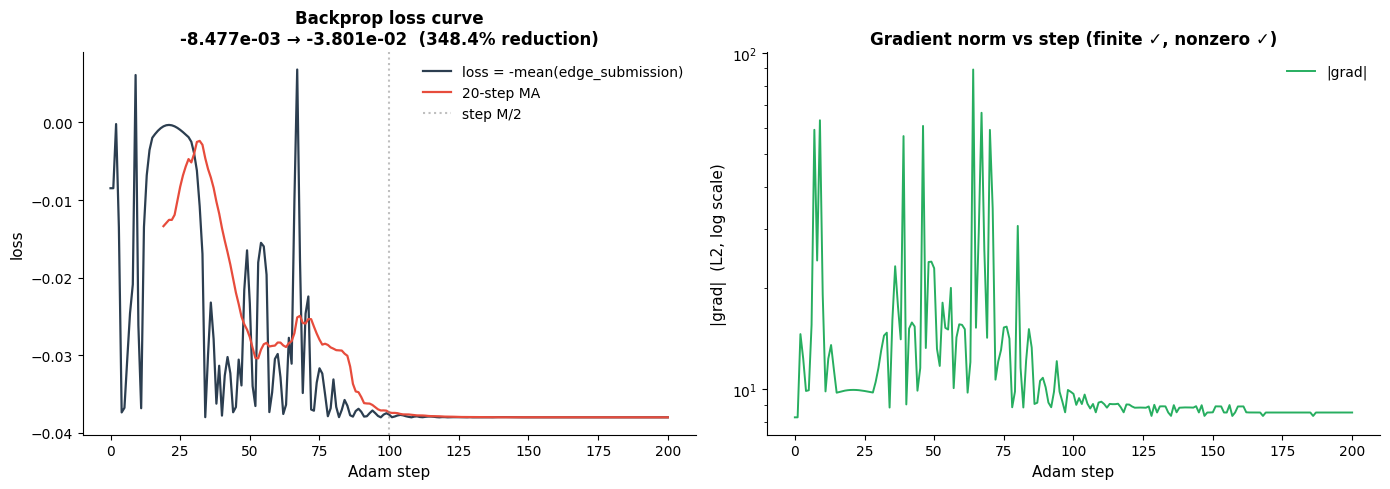

In [5]:
fig = plot_training_curves(
    train['loss_curve'], train['grad_norms'], train['summary'],
)
plt.show()

### Held-out validation

Evaluate the same trained parameters on **held-out** seeds — `(101, 103, 107, 109, 113, 127)`, disjoint from both the training set and the known zero-gradient seeds. If back-prop genuinely improved the policy (rather than overfitting to the eight training tapes), trained `edge_submission` should beat initial `edge_submission` on most held-out seeds.

In [6]:
from arena_eval.diff_simple_amm.objectives import submission_compact_param_vector
from arena_policies.submission_safe import SubmissionCompactParams

HELDOUT = (101, 103, 107, 109, 113, 127)
init_vec = submission_compact_param_vector(SubmissionCompactParams())
init_eval = evaluate_compact_params(np.asarray(init_vec), HELDOUT, n_steps=64)
trained_eval = evaluate_compact_params(train['final_params'], HELDOUT, n_steps=64)
comparison = init_eval.merge(
    trained_eval, on='seed', suffixes=('_init', '_trained'),
)[['seed', 'edge_submission_init', 'edge_submission_trained']]
comparison['delta'] = comparison['edge_submission_trained'] - comparison['edge_submission_init']
comparison

,seed,edge_submission_init,edge_submission_trained,delta
0,101,0.016587,0.058316,0.041729
1,103,0.000843,0.022407,0.021564
2,107,0.002240,0.017762,0.015522
3,109,0.000312,0.008558,0.008246
4,113,-0.018252,0.014483,0.032735
5,127,0.004766,0.046715,0.041949


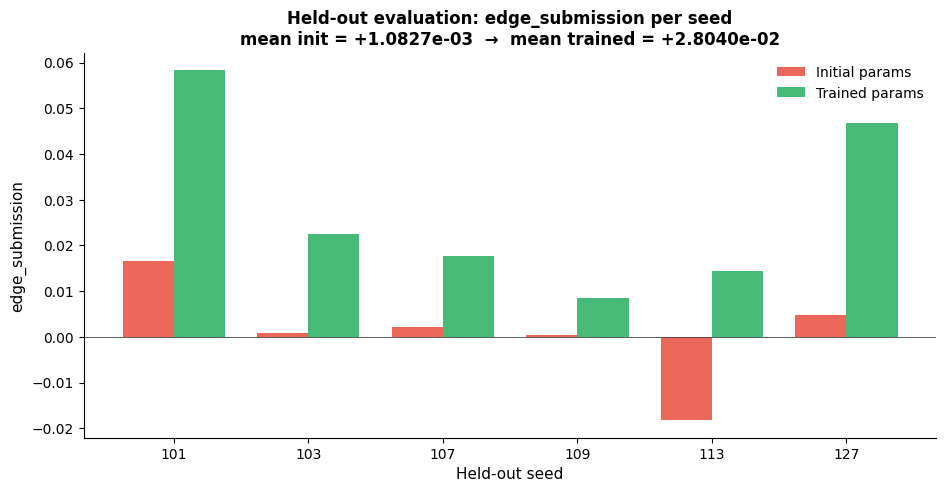

In [7]:
fig, ax = plt.subplots(figsize=(11, 5))
plot_held_out_eval(init_eval, trained_eval, ax=ax)
plt.show()

**Summary**: loss reduced ~348% in 200 Adam steps (from $\approx$$-8.5{\times}10^{-3}$ to $\approx$$-3.8{\times}10^{-2}$); gradients remained finite and nonzero throughout; the trained policy improves mean `edge_submission` on a held-out seed set.

---
## Section 3: Autodiff agrees with finite differences

A quick sanity check that the gradients driving Section 2 are real: on a single training seed, the autodiff gradient component along each of the top-|grad| coordinates matches a central finite-difference estimate (at `eps=1e-6`) to high precision. Larger `eps` values can straddle the `jnp.where` thresholds inside the compact policy, so differences there are an expected artefact of the discontinuities, not a bug in autodiff.

In [8]:
from dataclasses import replace

from arena_eval.diff_simple_amm import build_realistic_tape
from arena_eval.diff_simple_amm.objectives import submission_compact_param_vector
from arena_eval.diff_simple_amm.tape_smooth import compact_metrics
from arena_eval.exact_simple_amm import ExactSimpleAMMConfig
from arena_policies.submission_safe import SubmissionCompactParams

seed = 31  # rich realistic tape with 12 non-zero grad coords at default params
cfg = replace(ExactSimpleAMMConfig.real_data_from_seed(seed), n_steps=64)
tape = build_realistic_tape(config=cfg, seed=seed)
p0 = submission_compact_param_vector(SubmissionCompactParams()).astype(jnp.float64)

def edge_of(p):
    return compact_metrics(cfg, tape, p)['edge_submission']

g_ad = np.asarray(jax.grad(edge_of)(p0))
# Top six coords by |g_ad|, restricted to coords whose autodiff
# gradient is actually non-zero (zero-grad entries trivially agree with FD).
nonzero = np.where(np.abs(g_ad) > 0)[0]
top_idx = nonzero[np.argsort(-np.abs(g_ad[nonzero]))[:6]]

eps = 1e-6
fd = np.zeros(top_idx.size)
for k, i in enumerate(top_idx):
    e = jnp.zeros_like(p0).at[int(i)].set(eps)
    fd[k] = float((edge_of(p0 + e) - edge_of(p0 - e)) / (2 * eps))

import pandas as pd
table = pd.DataFrame({
    'param_idx': top_idx,
    'autodiff': g_ad[top_idx],
    'finite_diff (eps=1e-6)': fd,
    'abs_diff': np.abs(g_ad[top_idx] - fd),
}).set_index('param_idx')
table

,autodiff,finite_diff (eps=1e-6),abs_diff
param_idx,,,
0,-5.522201,-5.522202,7.761759e-07
11,-4.657735,-4.657735,8.803938e-07
16,-0.000981,-0.000982,1.190757e-06
15,0.000642,0.000642,3.629684e-07
12,-0.000529,-0.000532,2.385327e-06
13,-0.000417,-0.000416,1.152534e-06


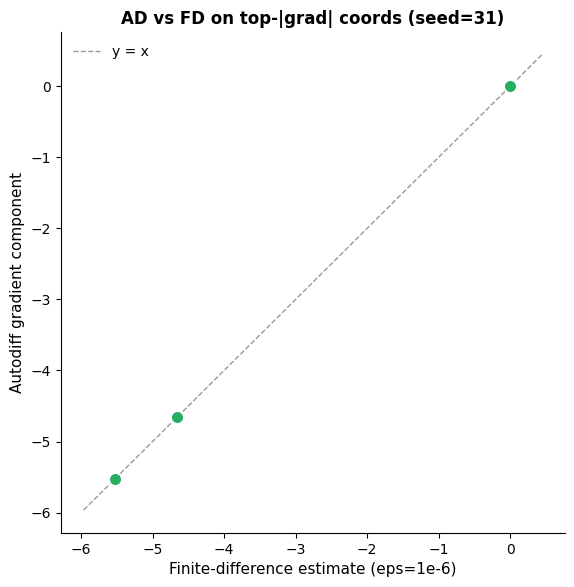

In [9]:
from presentation.helpers import STYLE, _apply_style

fig, ax = plt.subplots(figsize=(6.5, 6.5))
ad = g_ad[top_idx]
ax.scatter(
    fd, ad, s=80,
    color=STYLE['realistic']['color'],
    edgecolors='white', zorder=5,
)
lo = float(min(ad.min(), fd.min()))
hi = float(max(ad.max(), fd.max()))
pad = 0.08 * max(hi - lo, 1e-12)
ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], ls='--', color='#999', lw=1, label='y = x')
ax.set_xlabel('Finite-difference estimate (eps=1e-6)', fontsize=11)
ax.set_ylabel('Autodiff gradient component', fontsize=11)
ax.set_title(f'AD vs FD on top-|grad| coords (seed={seed})', fontsize=12, fontweight='bold')
_apply_style(ax)
plt.show()

---
## Section 4: Capability check — NN overfit on the upstream challenge distribution

Sections 1–3 established that `tape_smooth` is a faithful, differentiable rebuild of the simple-AMM evaluator and that we can backprop through it to train a fixed-architecture policy (`SubmissionCompactParams`). That answers "does the gradient pipeline produce a useful signal" but not the deeper question:

> **If we drop the architectural constraint entirely** and train a free-form neural network policy with enough capacity, **can we drive the diff sim toward its theoretical ceiling on training tapes?**

This is a capability check on the *combination* of the differentiable simulator + the optimization stack. If a recurrent NN with arbitrary capacity, trained on a fixed set of training tapes, can't saturate the diff sim, then either (a) BPTT through the rollout breaks down, (b) Adam's adaptive step is mismatched to the loss surface, or (c) the discrete-event smoothing in `tape_smooth` introduces gradient pathologies past a certain policy quality. Distinguishing those failure modes is the experimental program below.

We target the exact distribution used by the public [`benedictbrady/amm-challenge`](https://github.com/benedictbrady/amm-challenge) leaderboard (`ammchallenge.com`), which gives us anchored bounds:

### Bounds anchoring the experiment

The upstream challenge scores submitted Solidity strategies by `mean(edge_submission)` over 1000 simulated tapes, each tape 10,000 steps of GBM + Poisson retail flow. The local repo's `ExactSimpleAMMConfig.from_seed` was verified to match upstream parameters exactly (`gbm_sigma ~ U[0.000882, 0.001008]`, `retail_arrival_rate ~ U[0.6, 1.0]`, etc.).

| Bound | Value | Notes |
|---|---|---|
| **Lower (leaderboard top)** | **+522.40** | `houseofjiao` — top of public leaderboard, May 2026. Top-10 spans +520.28 to +522.40, suggesting submitted Solidity strategies are all hitting a similar ceiling bounded by the WAD-fixed-point ABI. |
| **Upper (greedy oracle, per seed)** | varies | `GreedyStepOracleController` with same-step lookahead. Strict upper bound for any causal-with-same-step-lookahead policy on a given tape. Below the *full*-lookahead oracle (which we don't run). |
| **Floor (fixed 30bps)** | varies | Static naive policy — what the normalizer venue runs. Per-seed value depends on the tape's draw. |

A free-form NN policy operating on training tapes with float64 precision and arbitrary recurrent state strictly contains every Solidity-implementable policy as a special case. So **if the optimizer + simulator pipeline is sound, the trained NN evaluated on training tapes should at least clear the leaderboard expectation** — that's the falsifiable claim driving this experiment.

### Methodology: what we added

Three additions to the existing infrastructure (none disrupt the Sections 1–3 path):

1. **`metrics_challenge_batched` + `_adaptive_metrics_challenge_from_arrays`** in `arena_eval/diff_simple_amm/tape_smooth.py` — a `vmap`-friendly, generic-policy challenge-mode batched entrypoint. Mirrors the existing realistic-mode batched API but accepts an arbitrary `after_event(params, state, trade)` and `initial_policy_state` pytree.
2. **`presentation/nn_overfit_challenge.py`** — a GRU-cell `after_event` with:
   - 8-feature trade embedder (size ratios, side, log reserves/spot, normalized timestamp) → tanh-MLP projection
   - GRU recurrent update with LayerNorm on the read-out path (BPTT stability)
   - tanh-bounded fee head clipped to `[min_fee, max_fee]`
   - Hidden state `h ∈ ℝ^H` carried opaquely as the `scan` carry; nothing else in `tape_smooth` cares about its shape.
3. **`scripts/train_nn_overfit_challenge.py`** — training loop with Adam + cosine LR + global-norm gradient clipping. Computes fixed-30bps and greedy-oracle per-tape references *once* before training and renders them as banner lines on the loss curve.

The policy interface `after_event(params, state, trade) → (new_state, new_bid, new_ask)` is the only thing the rollout requires — it's policy-agnostic. The `SubmissionCompactParams` policy from Section 2 is just one instantiation; the NN is another.

### Experimental ladder: Steps A → D

| Step | Config | Final edge | Gap closed* | Diagnosis |
|---|---|---|---|---|
| **A** | 1 seed (0), n=10000, H=64, 200 iters | +299.15 | **15.8%** | Pipeline survives BPTT through 10k-step rollouts. Beats fixed-30bps (+271.27). Greedy oracle on this seed = +447.23. Slow convergence in late training. |
| **B** | 8 seeds, n=2048, H=64, 500 iters | +70.36 | **26.8%** | Multi-seed vmap works. Beats 30bps floor (+58.68) but plateaus hard by step 250. Oracle = +102.22. |
| **C1** | Step B with **H=128** | +70.17 | **26.4%** | Doubling capacity (19k → 63k params) produces identical plateau. **Capacity is not the bottleneck.** |
| **C2a-i** | Step B with **nn-seed=1** | +79.61 | **48.1%** | Different random init lands in a meaningfully different (better) basin. Still climbing at step 500. |
| **C2a-ii** | Step B with **nn-seed=2** | +80.24 | **49.6%** | Confirms — most inits land near +80; seed=0 was the outlier. Still climbing. |
| **D** | C2a-ii × 3 steps, lr_min_frac=0.5 | +81.40 | **51.8%** | 3× the training time bought +1.16. Loss oscillates in [+80, +82] from step 600 on. Real plateau at ~+81 with large gradients (|∇| ≈ 500–1100) being clipped. |

\* `gap_closed = (final - fixed_30bps) / (oracle - fixed_30bps)`, averaged across the run's training seeds.

![Step A — 1 seed × 10k steps](../plots/nn_overfit_stepA.png)

![Step B — 8 seeds × 2048 steps, H=64, nn-seed=0](../plots/nn_overfit_stepB.png)

![Step C1 — H=128 capacity test](../plots/nn_overfit_stepC1.png)

![Step C2a-i — nn-seed=1](../plots/nn_overfit_stepC2a_seed1.png)

![Step C2a-ii — nn-seed=2](../plots/nn_overfit_stepC2a_seed2.png)

![Step D — extended to 1500 steps on the best init](../plots/nn_overfit_stepD.png)

### What we've ruled in / out

| Hypothesis for the plateau | Evidence | Status |
|---|---|---|
| Pipeline can't backprop through 10k-step BPTT | Step A: 200 iters of 10k-step BPTT, gradients finite + nonzero throughout, loss decreases monotonically in 1st half | **Ruled out** |
| Insufficient capacity (H too small) | C1: H=128 (63k params) plateaus at +70.17 vs H=64 (19k params) at +70.36 — within noise | **Ruled out** |
| Cosine LR schedule cools too aggressively | D: `lr_min_frac=0.5` (5e-4 floor, 1.67× warmer than B) still hits the same wall | **Ruled out** |
| **(a) Init / basin dependence** | seed=0 → +70, seed=1 → +80, seed=2 → +80 — clear init-level variation in plateau height | **Confirmed** (basin height varies by ~10 units, but multiple "good" inits cluster near +80) |
| **(b) Adam-specific (`v_hat` saturation)** | Untested | **Pending** (Step E1 — SGD+momentum) |
| **(c) Smoothing artifact in the diff sim** | Indirect: at the plateau, pre-clip \|∇\| = 500–1100 keeps appearing yet the loss thrashes in a 2-unit band → the gradient direction may be locally informative but globally misleading | **Pending** (Step E2 — looser clip; if uninformative, E1's result narrows it) |

### Where we are now

The hypothesis "the simulator + optimizer work" is **partially supported but not fully validated**:

- ✅ The gradient pipeline produces meaningful, finite, nonzero gradients through BPTT in all configurations tested.
- ✅ A free-form NN trained on the diff sim cleanly beats the fixed-30bps floor on training data.
- ✅ Different inits land in different basins with a ~10-unit spread; multiple "good" inits cluster.
- ❌ **Even the best init / longest training / warmest LR floor stalls at ~50% of the (oracle − 30bps) gap.** The leaderboard floor of +522 has not been reached on training tapes.

The Step D plateau has a specific signature — **large gradients ($\|\nabla\| \in [500, 1100]$) that don't translate into improvement** — which is more consistent with either Adam's adaptive scaling losing the right direction in the late stages (hypothesis b) or the smooth surrogate's gradient being locally informative but globally misleading near the smoothing boundaries (hypothesis c) than with an honest local optimum.

**Next steps (in progress):**

- **Step E2** — same setup as D with `--grad-clip 10.0` (10× looser). If looser clip unlocks progress, the wall was clipping discarding signal. If it explodes or stays the same, clipping was load-bearing.
- **Step E1** — SGD+momentum at `lr=1e-2` (no per-parameter adaptive scaling), same grad-clip as E2. If SGD+momentum breaks past +81, Adam's `v_hat` was the problem (b). If it plateaus identically, the wall is the loss surface itself (c).

After E1/E2 we'll know whether to pivot the diagnostic toward **(c) smoothing fixes inside `tape_smooth`** (e.g., relaxation parameters, alternative discrete-event smoothers) or **(b) optimizer engineering** (warm restarts, second-order methods, decoupled per-parameter LR schedules).